In [4]:
from google.colab import files
uploaded = files.upload()

Saving sales_data_cleaned.csv to sales_data_cleaned.csv


In [5]:
import pandas as pd

df = pd.read_csv("sales_data_cleaned.csv")
df.head()

,ordernumber,quantityordered,priceeach,orderlinenumber,sales,orderdate,status,qtr_id,month_id,year_id,...,addressline1,addressline2,city,state,postalcode,country,territory,contactlastname,contactfirstname,dealsize
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,897 Long Airport Avenue,Not Provided,Nyc,Ny,10022,Usa,Unknown,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,59 rue de l'Abbaye,Not Provided,Reims,Unknown,51100,France,Emea,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,Not Provided,Paris,Unknown,75508,France,Emea,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,78934 Hillside Dr.,Not Provided,Pasadena,Ca,90003,Usa,Unknown,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,7734 Strong St.,Not Provided,San Francisco,Ca,Unknown,Usa,Unknown,Brown,Julie,Medium


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ordernumber       2823 non-null   int64  
 1   quantityordered   2823 non-null   int64  
 2   priceeach         2823 non-null   float64
 3   orderlinenumber   2823 non-null   int64  
 4   sales             2823 non-null   float64
 5   orderdate         2823 non-null   object 
 6   status            2823 non-null   object 
 7   qtr_id            2823 non-null   int64  
 8   month_id          2823 non-null   int64  
 9   year_id           2823 non-null   int64  
 10  productline       2823 non-null   object 
 11  msrp              2823 non-null   int64  
 12  productcode       2823 non-null   object 
 13  customername      2823 non-null   object 
 14  phone             2823 non-null   object 
 15  addressline1      2823 non-null   object 
 16  addressline2      2823 non-null   object 


Observation:
The dataset contains sales transaction records with customer, product, country, and revenue information.

In [7]:
df.describe()

,ordernumber,quantityordered,priceeach,orderlinenumber,sales,qtr_id,month_id,year_id,msrp
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


Observation:
The dataset contains a wide range of sales values, indicating varying transaction sizes.

In [8]:
df.isnull().sum()

,0
ordernumber,0
quantityordered,0
priceeach,0
orderlinenumber,0
sales,0
orderdate,0
status,0
qtr_id,0
month_id,0
year_id,0


Observation:
No significant missing values were found in the cleaned dataset.

In [9]:
df["country"].value_counts().head(10)

,count
country,
Usa,1004
Spain,342
France,314
Australia,185
Uk,144
Italy,113
Finland,92
Norway,85
Singapore,79


Observation:
USA appears most frequently in the dataset.

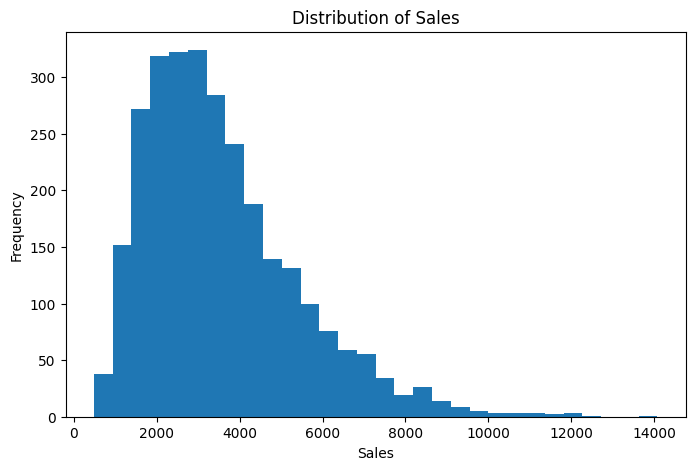

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Observation:
Most sales fall within lower ranges while a few transactions have very high values.

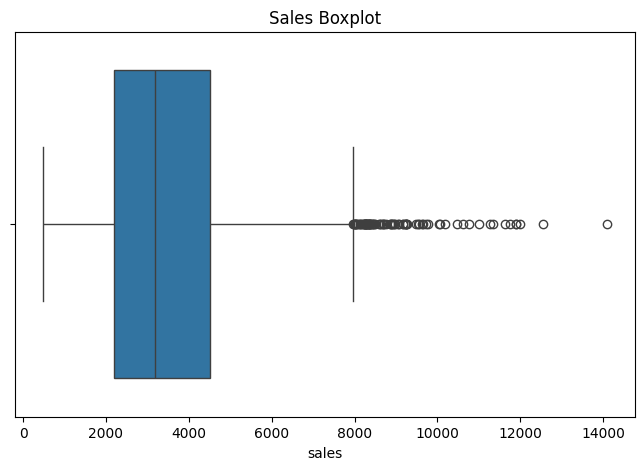

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["sales"])
plt.title("Sales Boxplot")
plt.show()

Observation:
Several outliers are present in the sales distribution.

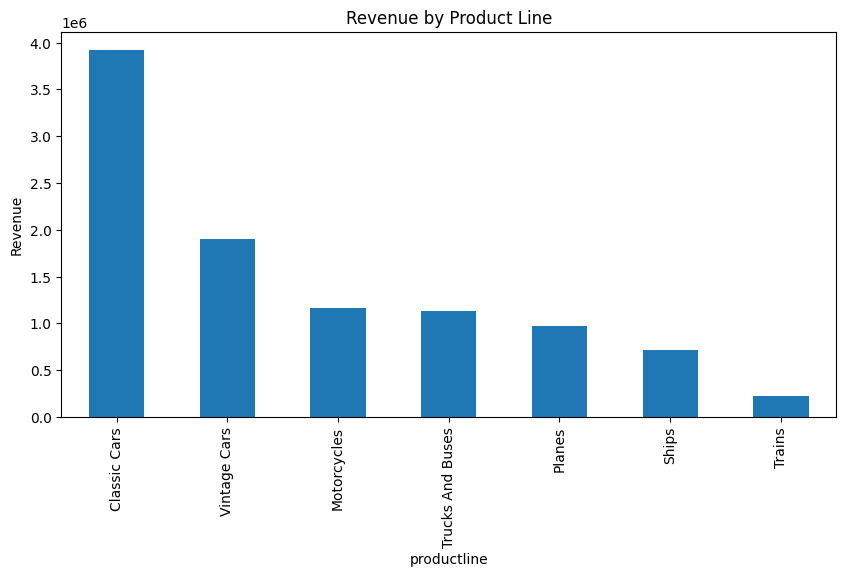

In [12]:
product_sales = df.groupby("productline")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_sales.plot(kind="bar")
plt.title("Revenue by Product Line")
plt.ylabel("Revenue")
plt.show()

Observation:
Classic Cars generate the highest revenue among product categories.

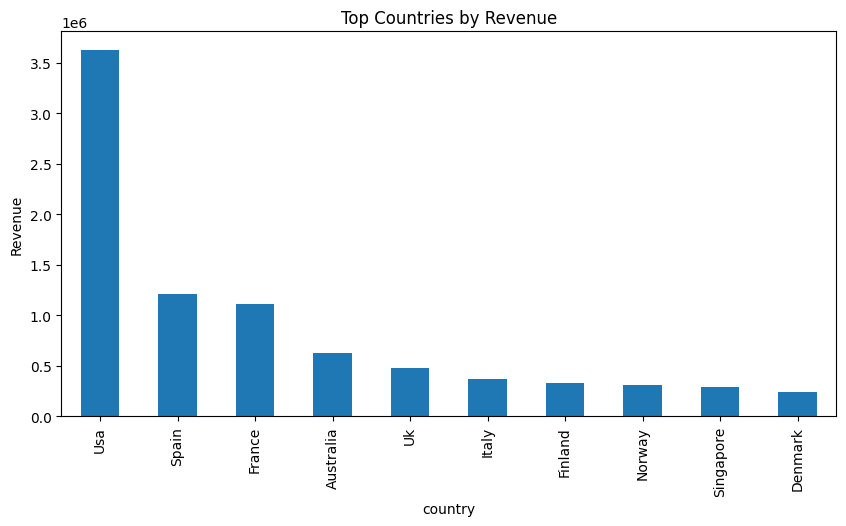

In [13]:
country_sales = df.groupby("country")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_sales.plot(kind="bar")
plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

Observation:
USA contributes the highest revenue.

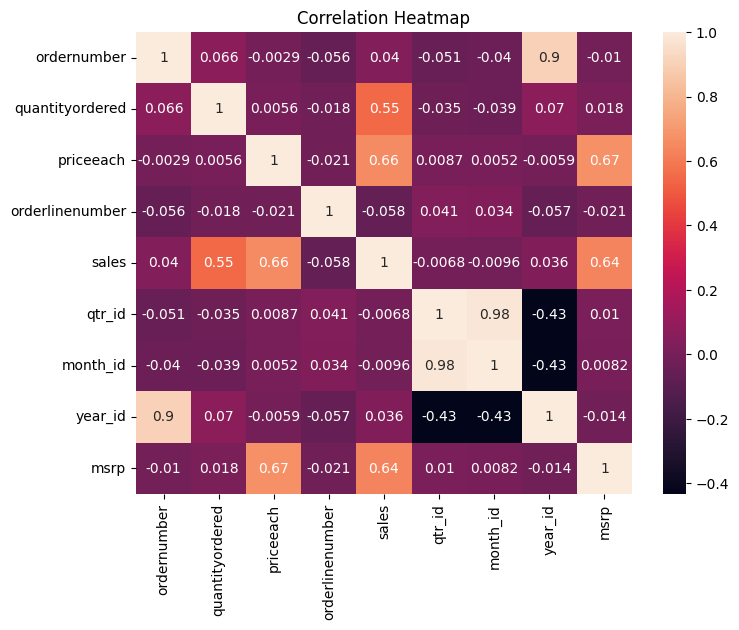

In [14]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Observation:
The heatmap helps identify relationships among numerical variables.

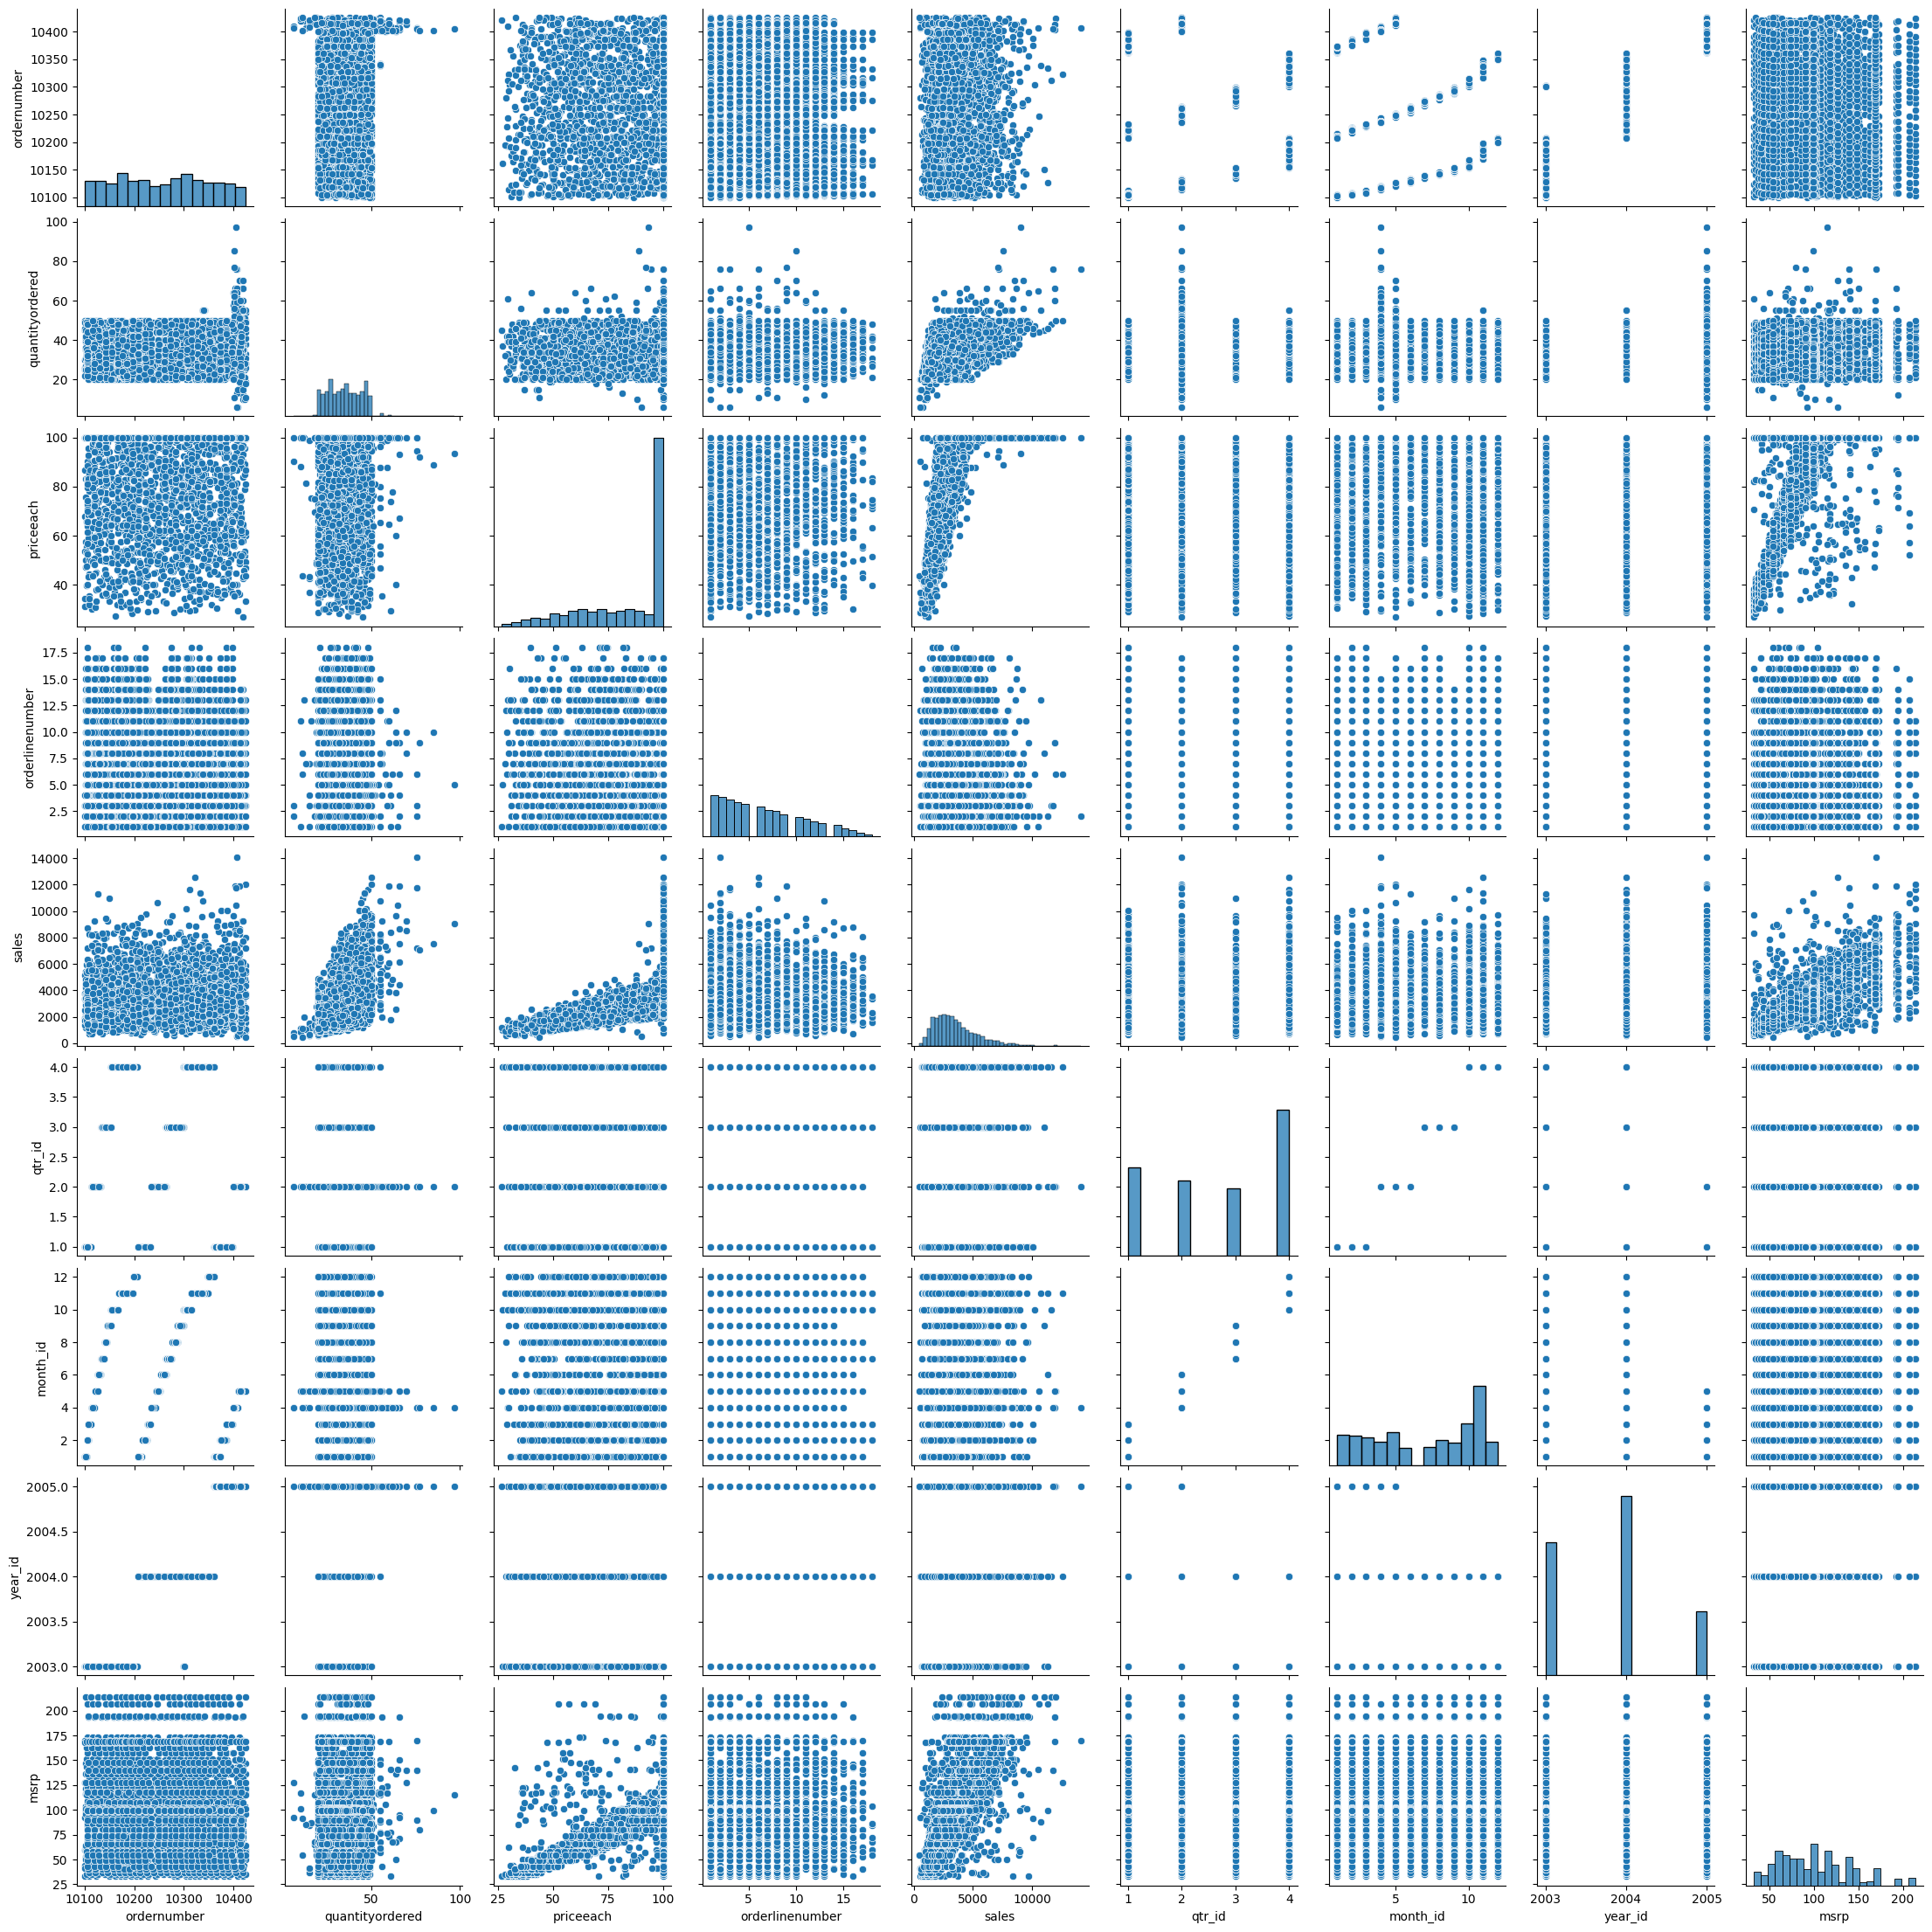

In [15]:
sns.pairplot(numeric_df)
plt.show()

Observation:
The pairplot visualizes relationships and patterns between numerical variables.

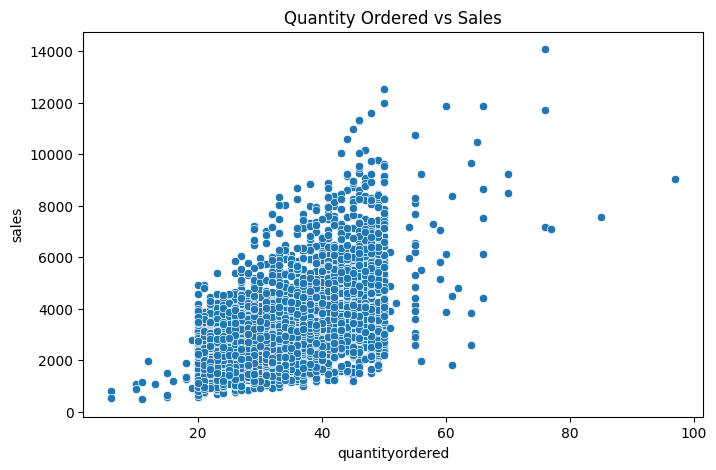

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["quantityordered"], y=df["sales"])
plt.title("Quantity Ordered vs Sales")
plt.show()

Observation:
Sales generally increase as quantity ordered increases.

**SUMMARY OF FINDINGS**

 • USA generated the highest revenue.

• Classic Cars was the top-performing product line.

• Several outliers were detected in sales data.

• Quantity ordered positively affects sales.

• Correlation analysis revealed relationships among numerical variables.

• EDA helped uncover patterns, trends, and anomalies in the dataset.